# BIOS 740: Homework 4

In [33]:
import torch
import pytorch_lightning as pl
import os
import io
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import TQDMProgressBar
from torchvision.utils import make_grid
from torchvision.models import vgg16
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

In [2]:
os.environ['SLURM_NTASKS_PER_NODE'] = '4'

## 1. Data Exploration and Preprocessing

In [29]:
##########################################################
# TODO: Implement the T1T2Dataset class:
# 1. Initialize the dataset by loading the T1 and T2 image paths.
# 2. Implement the __len__ method to return the number of samples.
# 3. Implement the __getitem__ method to load and transform images.
##########################################################

class T1T2Dataset(Dataset):
    def __init__(self, data_dir, transform=None):
        
        # Step 1: Load and sort image paths
        self.t1_images = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if "_T1_" in f and f.endswith(".png")])
        self.t2_images = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if "_T2_" in f and f.endswith(".png")])
        self.transform = transform

    def __len__(self):
        
        # Step 2: Return the number of samples
        return len(self.t1_images)


    def __getitem__(self, idx):
        
        # Step 3: Load images and apply transformations
        t1_image = Image.open(self.t1_images[idx]).convert("L")
        t2_image = Image.open(self.t2_images[idx]).convert("L")

        if self.transform:
            t1_image = self.transform(t1_image)
            t2_image = self.transform(t2_image)

        return t1_image, t2_image

#############################################################
# END OF YOUR CODE
##########################################################

In [30]:
# Transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Create Dataset and DataLoaders
dataset = T1T2Dataset(
    data_dir='img/pair_slices/',
    transform=transform
)

In [31]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)

In [32]:
print(len(dataset))
t1, t2 = dataset[0]
print(t1.shape)
print(t2.shape)

19975
torch.Size([1, 256, 256])
torch.Size([1, 256, 256])


#### Data Loading: 

Dataset is of paired samples of T1 and T2 MRI image slices. There are 19975 paired samples. After preprocessing, each individual sample is of size [1, 256, 256] for T1 and T2. 1 represents the number of channels (1 for greyscale) and 256 represents the dimensions of the image. 


#### Preprocessing: 

- Convert: ensure greyscale for consistency among all images during training

- Resize: 256 x 256 to keep size consistency among all images during training

- ToTensor: convert to PyTorch tensor to be used in model

- Normalize: scale image from [0,1] to [-1, 1] to improve convergence of model and give equal range of value to all features

## 2. GAN Architecture

NOTE: architecture inspired by https://arxiv.org/pdf/1611.07004

In [7]:
##########################################################
# TODO: Implement the UNetGenerator class:
# 1. Define the encoder (downsampling) layers.
# 2. Define the decoder (upsampling) layers with skip connections.
# 3. Implement the forward method to connect the layers.
##########################################################

class UNetGenerator(nn.Module):
    def __init__(self, input_channels=1, output_channels=1, num_filters=64):
        super(UNetGenerator, self).__init__()
        # Step 1: Define the encoder layers
        self.down1 = self.conv_block(input_channels, num_filters, normalize=False)
        self.down2 = self.conv_block(num_filters, num_filters*2)
        self.down3 = self.conv_block(num_filters*2, num_filters*4)
        self.down4 = self.conv_block(num_filters*4, num_filters*4)
        self.down5 = self.conv_block(num_filters*4, num_filters*8)
        self.down6 = self.conv_block(num_filters*8, num_filters*8)
        self.down7 = self.conv_block(num_filters*8, num_filters*8)
        self.down8 = self.conv_block(num_filters*8, num_filters*8, normalize=False)

        # Step 2: Define the decoder layers

        self.up1 = self.deconv_block(num_filters*8, num_filters*8, dropout=0.3)  
        self.up2 = self.deconv_block(num_filters*16, num_filters*8, dropout=0.3) 
        self.up3 = self.deconv_block(num_filters*16, num_filters*8, dropout=0.3) 
        self.up4 = self.deconv_block(num_filters*16, num_filters*4) 
        self.up5 = self.deconv_block(num_filters*8, num_filters*4) 
        self.up6 = self.deconv_block(num_filters*8, num_filters*2)  
        self.up7 = self.deconv_block(num_filters*4, num_filters) 
        self.up8 = nn.Sequential(
            nn.ConvTranspose2d(num_filters*2, output_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def conv_block(self, in_channels, out_channels, normalize=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))
        return nn.Sequential(*layers)

    def deconv_block(self, in_channels, out_channels, dropout=0.0):
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Step 3: Implement the forward pass with skip connections

        d1 = self.down1(x)  # [B, 64, 128, 128]
        d2 = self.down2(d1) # [B, 128, 64, 64]
        d3 = self.down3(d2) # [B, 256, 32, 32]
        d4 = self.down4(d3) # [B, 256, 16, 16]
        d5 = self.down5(d4) # [B, 512, 8, 8]
        d6 = self.down6(d5) # [B, 512, 4, 4]
        d7 = self.down7(d6) # [B, 512, 2, 2]
        d8 = self.down8(d7) # [B, 512, 1, 1]

        u1 = torch.cat([self.up1(d8), d7], dim=1) # [B, 1024, 2, 2]
        u2 = torch.cat([self.up2(u1), d6], dim=1) # [B, 1024, 4, 4]
        u3 = torch.cat([self.up3(u2), d5], dim=1) # [B, 1024, 8, 8]
        u4 = torch.cat([self.up4(u3), d4], dim=1) # [B, 512, 16, 16]
        u5 = torch.cat([self.up5(u4), d3], dim=1) # [B, 512, 32, 32]
        u6 = torch.cat([self.up6(u5), d2], dim=1) # [B, 256, 64, 64]
        u7 = torch.cat([self.up7(u6), d1], dim=1) # [B, 128, 128, 128]
        u8 = self.up8(u7)                         # [B, 1, 256, 256]

        return u8

#############################################################
# END OF YOUR CODE
##########################################################

NOTE: architecture inspired by https://arxiv.org/pdf/1611.07004

In [8]:
##########################################################
# TODO: Implement the Discriminator class:
# 1. Define the convolutional layers of the discriminator.
# 2. Implement the forward method.
##########################################################

class Discriminator(nn.Module):
    def __init__(self, input_channels=2, num_filters=64):
        super(Discriminator, self).__init__() # [B, 2, 256, 256]
        
        # Step 1: Define the convolutional layers
        self.model = nn.Sequential(
            nn.Conv2d(input_channels, num_filters, kernel_size=4, stride=2, padding=1), # [B, 64, 128, 128]
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(num_filters, num_filters*2, kernel_size=4, stride=2, padding=1),  # [B, 128, 64, 64]
            nn.BatchNorm2d(num_filters*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(num_filters*2, num_filters*4, kernel_size=4, stride=2, padding=1),  # [B, 256, 32, 32]
            nn.BatchNorm2d(num_filters*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(num_filters*4, num_filters*8, kernel_size=4, stride=1, padding=1),  # [B, 512, 31, 31]
            nn.BatchNorm2d(num_filters*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(num_filters*8, 1, kernel_size=4, stride=1, padding=1), # [B, 1, 30, 30]
            nn.Sigmoid()
        )


    def forward(self, x):
        
        # Step 2: Implement the forward pass
        return self.model(x)

#############################################################
# END OF YOUR CODE
##########################################################

#### Generator Design:

NOTE: U-Net architecture inspired by https://arxiv.org/pdf/1611.07004

Inputs: [B, 1, 256, 256], where B = batch size, 1 = grayscale MRI channel, 256 × 256 spatial image dimensions for T1

Outputs: [B, 1, 256, 256], where B = batch size, 1 = grayscale MRI channel, 256 × 256 spatial image dimensions for translated T2


##### Encoder:

Convolution Block: 8 total
* All 8 blocks: Conv2D → Batch Normalization (except first and last layer) → LeakyReLu

##### Decoder:

Deconvolution Block: 8 total
* First 7 blocks: ConvTranspose2D → Batch Normalization → LeakyReLu
* Last block: ConvTranspose2D → Tanh


##### Layer Details: 

Convolution layers:
* extract hierarchical features
* gradually increase channels to learn more complex structures (1 → 64 → 128 → 256 → 256 → 512 → 512 → 512 → 512)
* reduce spatial dimensions

Transposed convolution layers: 
* decrease channels for reconstruction (512 → 512 → 512 → 256 → 256 → 128 → 64 → 1)
* reconstruct spatial resolution

Activation Functions: 
* LeakyReLU: 0.2 slope
    * like ReLU
    * prevents dead neurons
* ReLU: 
    * introduces non-linearity
    * prevents vanishing gradients
* Tanh: 
    * maps output to [-1,1] to match with normalize image range

Normalization Layers:
* Batch Normalization
    * stabalize training
    * normalize feature distributions


##### Design Decisions: 

Kernel Size: 4 × 4
* preserve dimensionaity with padding
* small size to catch local patterns

Stride: 2
* downsampling: halves spatial dimensions
* upsampling: doubles spatial dimensions

Padding: 1
* ensures features near edge of data to be included by adding a one-border pixel
* preserve spatial dimension with the given kernel size and strides

Skip connections: 
* used between corresponding encoder and decoder layers to preserve high-resolution spatial details (U1 with D7, U2 with D6, ..., U7 with D1)
* improve gradient flow

Regularization Techniques: 
* Dropout: 0.3 rate
    * reduces overfitting
* Batch Normalization
    * stabalize training
    * normalize feature distributions
     
Other: 
* Encoder:
    * Batch Normalization not in first layer
        * don't want to accidentally remove useful information
    * Batch Normalization not in last layer
        * don't want to change distribution of values before decoder
* Decoder:
    * Dropout in first 3 layers
        * don't want to remove spatial information on large feature maps

Input, Intermediate, Output Dimensions:

ENCODER

Input: [B, 1, 256, 256]

D1: [B,  64, 128, 128]

D2: [B, 128, 64, 64]

D3: [B, 256, 32, 32]

D4: [B, 256, 16, 16]

D5:[B, 512, 8, 8]

D6: [B, 512, 4, 4]

D7: [B, 512, 2, 2]

D8: [B, 512, 1, 1] (LATENT)

DECODER

U1: [B, 1024, 2, 2] 

U2: [B,1024, 4, 4]

U3: [B,1024, 8, 8] 

U4: [B, 512, 16, 16]

U5: [B, 512, 32, 32] 

U6: [B, 256, 64, 64] 

U7: [B, 128, 128, 128]

U8/Output: [B, 1, 256, 256]

#### Discriminator Design:

NOTE: architecture inspired by https://arxiv.org/pdf/1611.07004

Inputs: [B, 2, 256, 256], where B = batch size, 2 = grayscale MRI channel for T1 and T2 combined, 256 × 256 spatial image dimensions for T1 and T2

Outputs: [B,  1, 30, 30], where B = batch size, 1 = grayscale MRI channel, 30 × 30 probability that image patch is real or fake

Convolution Block: 5 total
* First 4 blocks: Conv2D → Batch Normalization (except first) → LeakyReLu
* Last block: Conv2D → Sigmoid

##### Layer Details:

Convolution layers: 5 total
* extract hierarchical features
* gradually increase channels to learn more complex structures (1 → 64 → 128 → 256 → 256 → 512 → 512 → 512 → 512)
* * reduce spatial dimensions

Activation Functions: 
* LeakyReLU: 0.2 slope
    * like ReLU
    * prevents dead neurons
* Sigmoid
    * maps output to [0,1] for probability values

Normalization Layers:
* Batch Normalization
    * stabalize training
    * normalize feature distributions

##### Design Decisions: 

Kernel Size: 4 × 4
* preserve dimensionaity with padding
* small size to catch local patterns

Stride:
* First 4 layers: halves spatial dimensions, 2
* Last layer: convert dimension to even number, 1

Padding: 1
* ensures features near edge of data to be included by adding a one-border pixel
* preserve spatial dimension with the given kernel size and strides

Regularization Techniques:  
* Batch Normalization
    * stabalize training
    * normalize feature distributions

Other:
* Batch Normalization not in first layer of encoder
    * don't want to accidentally remove useful information
* Batch Normalization not in last layer of encoder
    * don't want to change distribution of values before assigning a probability

Input, Intermediate, Output Dimensions:

Input:  [B, 2, 256, 256]

B1:  [B, 64, 128, 128]

B2:  [B, 128, 64, 64]

B3:  [B, 256, 32, 32]

B4:  [B, 512, 31, 31]

B5/Output: [B, 1, 30, 30]


## 3. Training and Validation

In [9]:
##########################################################
# TODO: Implement the Pix2PixModel class:
# 1. Implement the training_step for both generator and discriminator.
# 2. Implement the validation_step to compute evaluation metrics.
##########################################################
class Pix2PixModel(pl.LightningModule):
    def __init__(self, lr=2e-4, beta1=0.5):
        super(Pix2PixModel, self).__init__()
        self.generator = UNetGenerator()
        self.discriminator = Discriminator()
        self.lr = lr
        self.beta1 = beta1
        self.loss_gan = nn.BCELoss()
        self.loss_l1 = nn.L1Loss()
        # Load pre-trained VGG16 for perceptual loss
        self.vgg = vgg16(pretrained=True).features[:16].eval()
        for param in self.vgg.parameters():
            param.requires_grad = False
        self.save_hyperparameters()

        # Enable manual optimization
        self.automatic_optimization = False
        
    def perceptual_loss(self, gen, target):
        # gen and target are [batch_size, 1, H, W]
        # Duplicate channels to convert to 3-channel images
        gen_rgb = gen.repeat(1, 3, 1, 1)  # Now gen_rgb is [batch_size, 3, H, W]
        target_rgb = target.repeat(1, 3, 1, 1)

        # Normalize using ImageNet mean and std
        mean = torch.tensor([0.485, 0.456, 0.406], device=gen.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=gen.device).view(1, 3, 1, 1)

        gen_rgb = (gen_rgb - mean) / std
        target_rgb = (target_rgb - mean) / std

        gen_features = self.vgg(gen_rgb)
        target_features = self.vgg(target_rgb)
        return F.l1_loss(gen_features, target_features)

    def forward(self, x):
        return self.generator(x)

    def configure_optimizers(self):
        optimizer_g = torch.optim.Adam(self.generator.parameters(), lr=self.lr, betas=(self.beta1, 0.999))
        optimizer_d = torch.optim.Adam(self.discriminator.parameters(), lr=self.lr, betas=(self.beta1, 0.999))
        return [optimizer_g, optimizer_d]

    def training_step(self, batch, batch_idx):
        # Step 1: Implement the training step for generator and discriminator
        real_A, real_B = batch  # real_A is T1, real_B is T2
        opt_g, opt_d = self.optimizers()
        # Adversarial ground truths
        valid = torch.ones(real_B.size(0), 1, 30, 30).type_as(real_B)
        fake = torch.zeros(real_B.size(0), 1, 30, 30).type_as(real_B)

        # -----------------
        #  Train Generator
        # -----------------
        # Generate fake images
        fake_B = self.generator(real_A)
        # Discriminator's opinion on the generated images
        pred_fake = self.discriminator(torch.cat([real_A, fake_B], dim=1))
        # Calculate generator loss
        loss_gan = self.loss_gan(pred_fake, valid)
        # L1 loss
        loss_l1 = self.loss_l1(fake_B, real_B)
        # Perceptual loss
        loss_perceptual = self.perceptual_loss(fake_B, real_B)
        # Total loss
        loss_G = loss_gan + 100 * loss_l1 + 10 * loss_perceptual

        # Optimize generator
        self.manual_backward(loss_G)
        opt_g.step()
        opt_g.zero_grad()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        # Real loss
        pred_real = self.discriminator(torch.cat([real_A, real_B], dim=1))
        loss_real = self.loss_gan(pred_real, valid)

        # Fake loss
        # Detach to avoid updating generator parameters
        fake_B_detached = fake_B.detach()
        pred_fake = self.discriminator(torch.cat([real_A, fake_B_detached], dim=1))
        loss_fake = self.loss_gan(pred_fake, fake)

        # Total discriminator loss
        loss_D = (loss_real + loss_fake) * 0.5

        # Optimize discriminator
        self.manual_backward(loss_D)
        opt_d.step()
        opt_d.zero_grad()

        # Logging losses
        self.log('loss_G', loss_G, prog_bar=True, on_step=True, on_epoch=True)
        self.log('loss_D', loss_D, prog_bar=True, on_step=True, on_epoch=True)

    def validation_step(self, batch, batch_idx):
        # Step 2: Implement the validation step to compute PSNR and SSIM
        real_A, real_B = batch
        fake_B = self.generator(real_A)

        # Denormalize images
        real_B_denorm = real_B * 0.5 + 0.5
        fake_B_denorm = fake_B * 0.5 + 0.5

        real_B_np = real_B_denorm.cpu().numpy()
        fake_B_np = fake_B_denorm.cpu().numpy()

        batch_psnr = 0
        batch_ssim = 0

        for i in range(real_B_np.shape[0]):
            real_img = real_B_np[i, 0]
            fake_img = fake_B_np[i, 0]

            psnr_value = psnr_metric(real_img, fake_img, data_range=1.0)
            ssim_value = ssim_metric(real_img, fake_img, data_range=1.0)

            batch_psnr += psnr_value
            batch_ssim += ssim_value

        avg_psnr = batch_psnr / real_B_np.shape[0]
        avg_ssim = batch_ssim / real_B_np.shape[0]

        self.log('val_psnr', avg_psnr, prog_bar=True)
        self.log('val_ssim', avg_ssim, prog_bar=True)

        if batch_idx == 0:
            grid = make_grid(
                torch.cat([real_A[:4], fake_B[:4], real_B[:4]], dim=0),
                nrow=4, normalize=True
            )
            self.logger.experiment.add_image('val_images', grid, self.current_epoch)


    def test_step(self, batch, batch_idx):
        real_A, real_B = batch
        fake_B = self.generator(real_A)

        # Denormalize images for metric computation
        real_B_denorm = real_B * 0.5 + 0.5  # Convert from [-1,1] to [0,1]
        fake_B_denorm = fake_B * 0.5 + 0.5

        # Convert tensors to numpy arrays
        real_B_np = real_B_denorm.cpu().numpy()
        fake_B_np = fake_B_denorm.cpu().numpy()

        # Initialize metric accumulators
        batch_psnr = 0
        batch_ssim = 0

        for i in range(real_B_np.shape[0]):
            real_img = real_B_np[i, 0] 
            fake_img = fake_B_np[i, 0]

            # Compute PSNR and SSIM
            psnr_value = psnr_metric(real_img, fake_img, data_range=1.0)
            ssim_value = ssim_metric(real_img, fake_img, data_range=1.0)

            batch_psnr += psnr_value
            batch_ssim += ssim_value

        # Average over batch
        avg_psnr = batch_psnr / real_B_np.shape[0]
        avg_ssim = batch_ssim / real_B_np.shape[0]

        self.log('test_psnr', avg_psnr, prog_bar=True)
        self.log('test_ssim', avg_ssim, prog_bar=True)

        # Optionally log images
        if batch_idx == 0:
            grid = make_grid(
                torch.cat([real_A[:4], fake_B[:4], real_B[:4]], dim=0),
                nrow=4, normalize=True
            )
            self.logger.experiment.add_image('test_images', grid, self.current_epoch)
#############################################################
# END OF YOUR CODE
##########################################################

In [44]:
# Train the Model
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | generator     | UNetGenerator | 45.0 M | train
1 | discriminator | Discriminator | 2.8 M  | train
2 | loss_gan      | BCELoss       | 0      | train
3 | loss_l1       | L1Loss        | 0      | train
4 | vgg           | Sequential    | 1.7 M  | eval 
--------------------------------------------------------
47.7 M    Trainable params
1.7 M     Non-trainable params
49.5 M    Total params
197.902   Total estimated model params size (MB)
82        Modules in train mode
17        Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_psnr improved. New best score: 26.285


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_psnr did not improve in the last 5 records. Best score: 28.499. Signaling Trainer to stop.


In [15]:
# Initialize Model and Trainer
model = Pix2PixModel()

##########################################################
# TODO: Set up the training process:
# 1. Initialize the Trainer with appropriate parameters.
# 2. Start the training process.
##########################################################

early_stop_callback = EarlyStopping(
    monitor='val_psnr',
    min_delta=0.00,
    patience=5,
    verbose=True,
    mode='max'
)
logger = TensorBoardLogger("lightning_logs", name="GAN")

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[early_stop_callback],
    logger=logger,
    check_val_every_n_epoch=1,
    deterministic=True,
    enable_progress_bar=True
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [10]:
# If you encountered error: ModuleNotFoundError: Neither `tensorboard` nor `tensorboardX` is available. Try `pip install`ing either.
# Please make sure you have tensorboard and tensorboardX installed as listed in the requirements.txt 
# Please try:
'''
from lightning_utilities.core.imports import RequirementCache

print(RequirementCache("tensorboard"))
print(RequirementCache("tensorboardx"))
'''
# Try restarting session if 
'''
Requirement 'tensorboard' met
Requirement 'tensorboardx' met
'''

"\nRequirement 'tensorboard' met\nRequirement 'tensorboardx' met\n"

In [11]:
print('model training is done.')
trainer.save_checkpoint("GAN.pth")

model training is done.


NameError: name 'trainer' is not defined

#### Adversarial Training Setup

Loss Functions: 
* Generator: Binary Cross-Entropy, L1, Perceptual
* Discriminator: Binary Cross-Entropy

Hyperparameters
* Learning Rate: 2e-4
* Batch Size: 16
* Latent Space Dimension: [B, 512, 1, 1]
* Training Epochs: max 50

Optimization Procedure
* Adam ($\beta_1$ = 0.5, $\beta_2$ = 0.999)


#### Monitoring Progress
Generator and discriminator losses are tracked and logged during training in lightning_logs using PyTorch Lightning. Generated images are also saved in lightning_logs. These logs allow visualization of adversarial loss curves and generated sample images to monitor model training and stability.

The code below shows how to retrieve the losses and plots the the adversairal loss curve. Some generated sample images are also shown from the 1st batch.

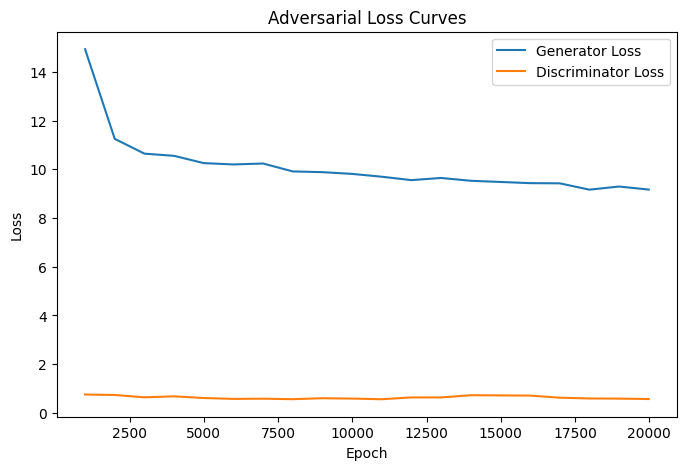

In [34]:
event = event_accumulator.EventAccumulator("lightning_logs/GAN/version_3")
event.Reload()

# loss curves
epochs = [x.step for x in event.Scalars('loss_G_epoch')]
loss_G = [x.value for x in event.Scalars('loss_G_epoch')]
loss_D = [x.value for x in event.Scalars('loss_D_epoch')]

plt.figure(figsize=(8,5))
plt.plot(epochs, loss_G, label='Generator Loss')
plt.plot(epochs, loss_D, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adversarial Loss Curves')
plt.legend()
plt.savefig('loss_curves.png', bbox_inches='tight')
plt.show()

In [16]:
# Test the Model
model = Pix2PixModel.load_from_checkpoint("GAN.pth")
trainer.test(model, test_loader)

You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_psnr         │    28.527925491333008     │
│         test_ssim         │    0.8346863985061646     │
└───────────────────────────┴───────────────────────────┘

[{'test_psnr': 28.527925491333008, 'test_ssim': 0.8346863985061646}]

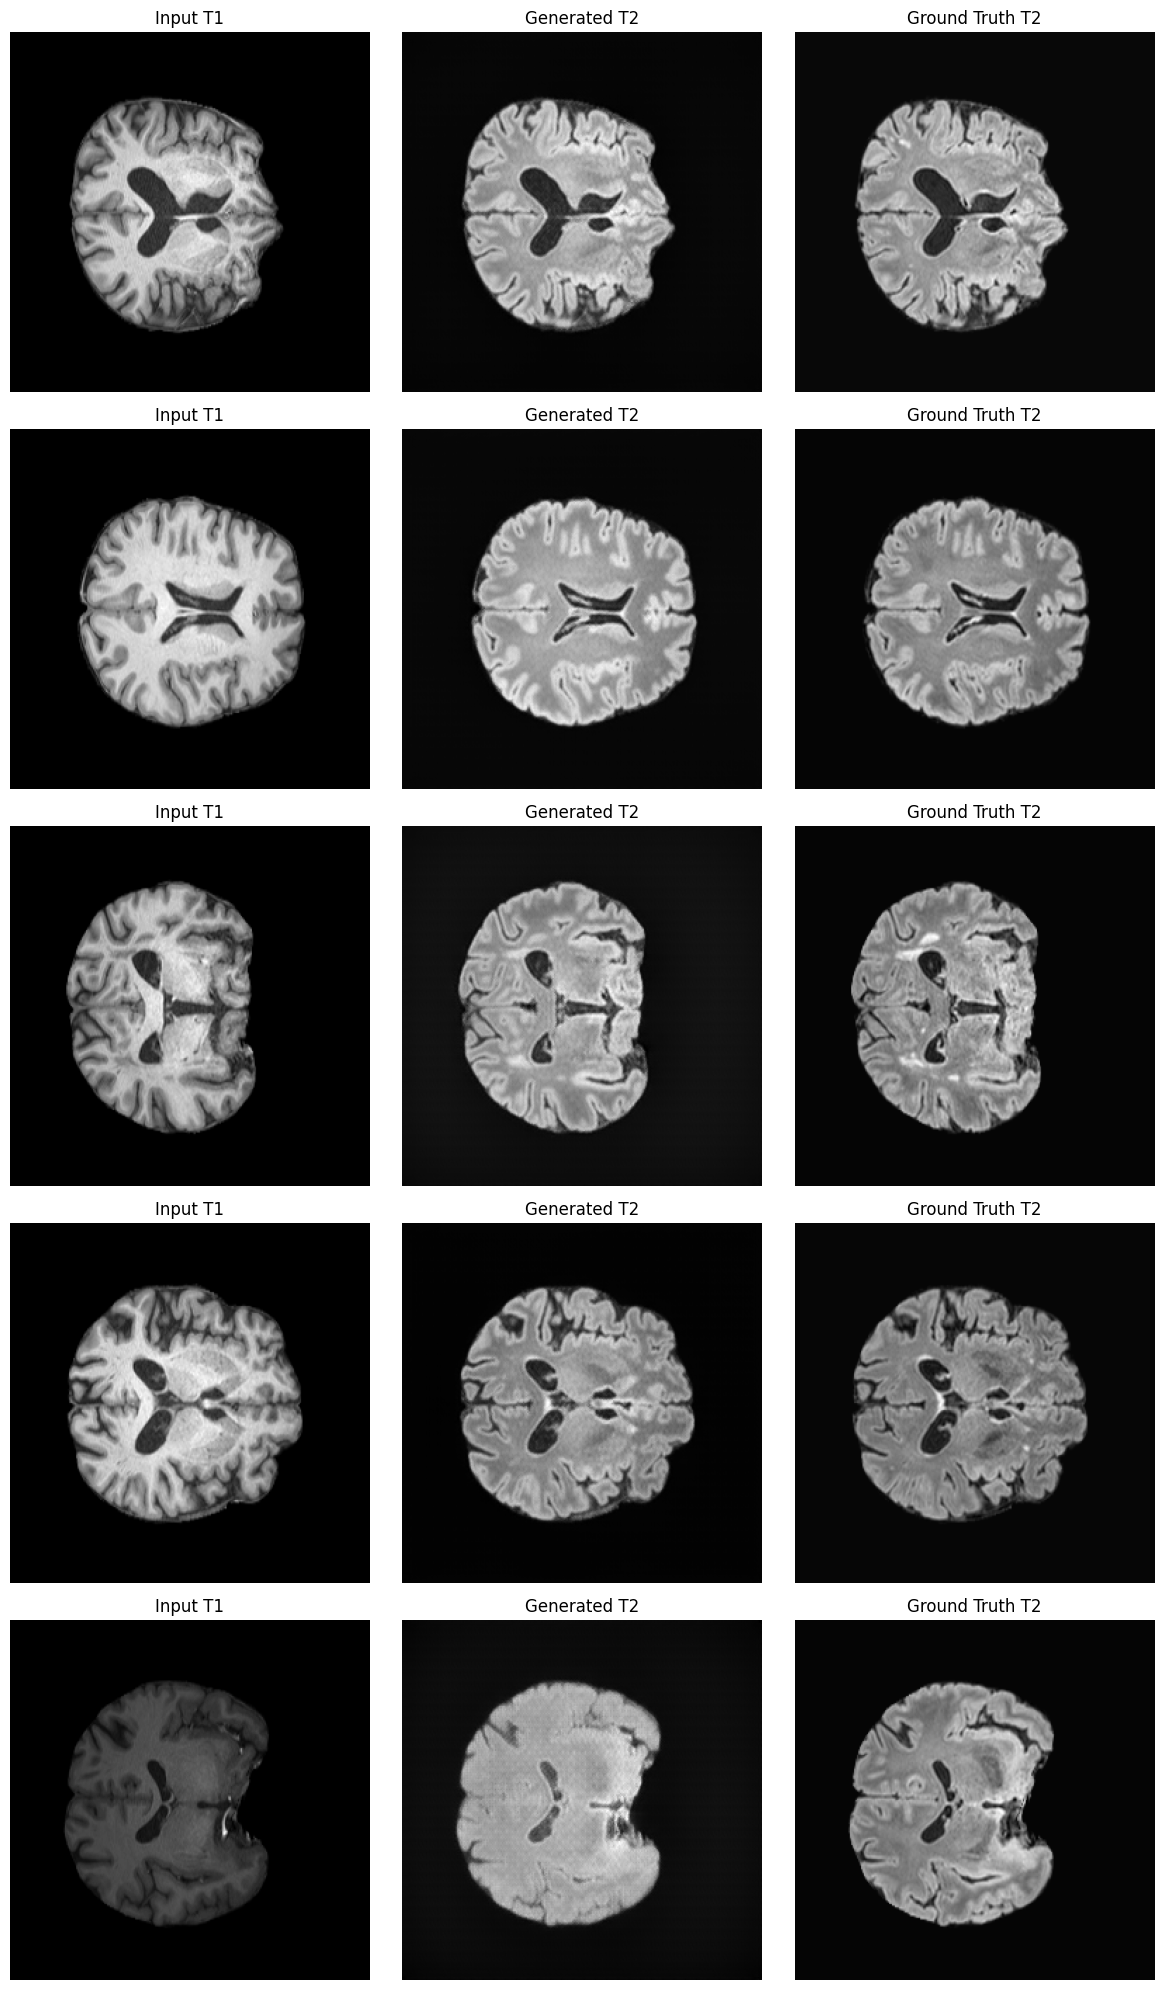

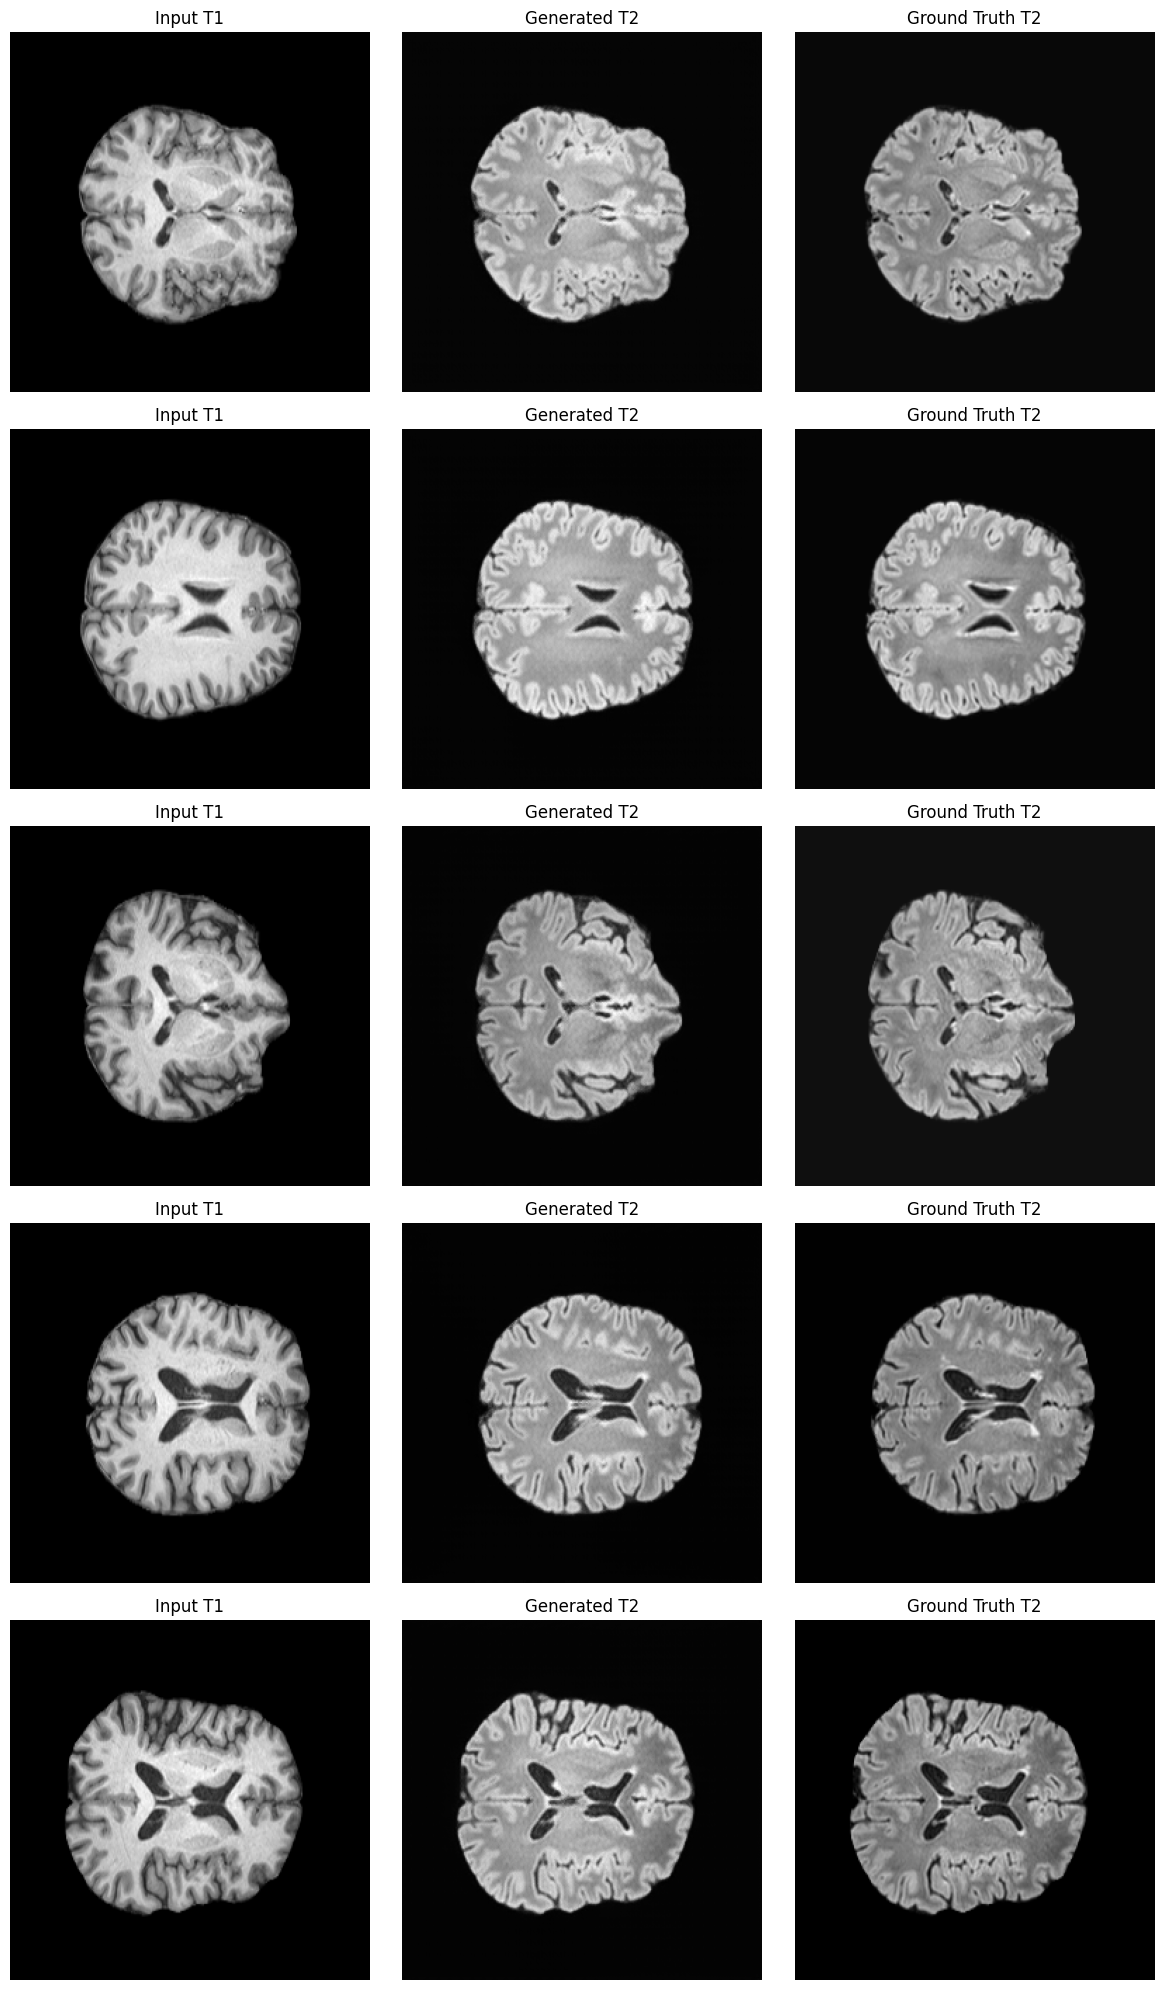

In [35]:
def visualize_results(model, dataloader, name, num_images=5):
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            real_A, real_B = batch
            fake_B = model.generator(real_A)

            # Denormalize images
            real_A = real_A * 0.5 + 0.5
            fake_B = fake_B * 0.5 + 0.5
            real_B = real_B * 0.5 + 0.5

            fig, axs = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

            # Plot images
            for i in range(num_images):
                axs[i, 0].imshow(real_A[i, 0].cpu(), cmap='gray')
                axs[i, 0].set_title('Input T1')

                axs[i, 1].imshow(fake_B[i, 0].cpu(), cmap='gray')
                axs[i, 1].set_title('Generated T2')

                axs[i, 2].imshow(real_B[i, 0].cpu(), cmap='gray')
                axs[i, 2].set_title('Ground Truth T2')

                for j in range(3):
                    axs[i, j].axis('off')

            plt.tight_layout()
            plt.savefig(f'generated_samples_{name}.png', bbox_inches='tight')
            plt.show()
            break # Only visualize one batch

# Visualize the results
visualize_results(model, test_loader, 'test')
visualize_results(model, val_loader, 'val')

## 4. Model Evaluation

#### Qualitative Assessment
Some generated sample test and validation images are also shown from the 1st batch above. The generated images appear close to the real images, with some noticeable differences in quality.

#### Quantitative Assessment
Peak Signal-to-Noise Ratio (PSNR) = 28.53 
* 28.53 > 20 db is acceptable $\implies$ GAN produces images with low reconstruction error

Structural Similarity Index (SSIM) = 0.84
* 0.84 close to 1 $\implies$ GAN captured most of the structural patterns in the T2 images

#### Discussion of Results

With the ok PSNR = 28.53 and the extremely high SSIM = 0.84, GAN has learned the distirbution of training set well instead of memorizing individual examples. Thus, it is generalizable to unseen test samples. 